# Decision Tree Regression

## Study notes: Decision Tree Regression overview

This notebook fits a decision tree to the Position Salaries dataset. **Position Level** is the single input feature, and **Salary** is the continuous target. These are not two features: the target is the value the model learns to predict.

The same scikit-learn implementation accepts any feature matrix shaped `(n_samples, n_features)`, so the code can also train on datasets containing several predictors. More columns do not automatically make the model appropriate, however; sample size, data quality, validation performance, and tree complexity still matter.

### How a regression tree learns

A decision tree recursively divides the feature space with threshold rules. With one feature, a rule may look like:

```text
Position Level <= 6.5
```

Each split creates smaller regions. A terminal region is called a **leaf**, and the prediction is constant for every observation assigned to that leaf. Under the default `criterion='squared_error'`, the leaf prediction is the mean target value of the training observations in that region.

The tree chooses splits that reduce target impurity. For squared-error regression, this means favoring partitions that reduce within-node variation in Salary. The final function is therefore **piecewise constant**, not a smooth line or curve.

### Why this one-feature dataset looks unusual

The dataset contains only ten ordered Position Levels. An unrestricted tree can create very narrow intervals and potentially place individual observations into separate leaves. Its graph then resembles a staircase: Salary remains constant within an interval and jumps abruptly at a learned threshold.

This does not mean decision tree regression requires multiple features. It means that a tiny one-dimensional dataset exposes the model's piecewise-constant structure very clearly and creates a high risk of memorizing the training observations.

> **No extrapolated trend:** A regression tree does not continue an upward or downward trend beyond the training range. Values below the smallest split or above the largest split remain in an outer leaf and receive that leaf's constant prediction.

### Why feature scaling is normally unnecessary

Decision trees split using comparisons such as `x_j <= threshold`. Standardizing a feature changes its numerical thresholds but preserves the ordering of its observations. A strictly monotonic rescaling therefore produces essentially the same partitions and predictions, apart from possible floating-point edge cases.

Consequently, this notebook does not need:

- `StandardScaler` for Position Level;
- a separate target scaler;
- transformed inputs at prediction time; or
- inverse transformation before interpreting Salary.

This is a property of threshold-based trees and tree ensembles such as random forests, not a universal preprocessing rule.

### Preprocessing that may still be required

Skipping feature scaling does not mean skipping all preprocessing. Depending on the data and scikit-learn workflow, you may still need to:

- investigate and handle missing or invalid values;
- encode categorical predictors appropriately;
- align feature columns consistently between training and prediction;
- prevent preprocessing leakage by learning transformations from training data only;
- inspect unusual observations and measurement errors; and
- choose metrics and validation splits suited to the regression problem.

> **Categorical-data caution:** Assigning arbitrary integers to categories can introduce an artificial order that a tree may split on. One-hot encoding or a carefully justified ordinal encoding is often safer, depending on the feature's meaning.

### Controlling overfitting

The notebook constructs `DecisionTreeRegressor(random_state=0)` with most complexity controls left at their defaults. Current scikit-learn documentation lists several important parameters:

| Parameter | Purpose |
|---|---|
| `max_depth` | Limits how many split levels the tree can grow |
| `min_samples_split` | Requires enough samples before an internal node may split |
| `min_samples_leaf` | Requires a minimum number of observations in every leaf and can smooth regression predictions |
| `max_leaf_nodes` | Places an upper limit on the number of terminal regions |
| `min_impurity_decrease` | Requires a split to improve impurity by at least a chosen amount |
| `ccp_alpha` | Applies cost-complexity pruning |
| `criterion` | Selects the split-quality measure, such as squared or absolute error |
| `random_state` | Makes randomized aspects of fitting reproducible |

With `max_depth=None` and `min_samples_leaf=1`, a small tree can grow until leaves are pure or too small to split. Tune complexity with cross-validation rather than choosing the tree that most closely follows the training observations.

### Training on the whole dataset

The tutorial fits all ten rows because it is demonstrating the model and estimating the salary at Position Level `6.5`. That approach uses every observation for training, but it leaves no independent data for measuring generalization.

A real comparison with polynomial regression, SVR, or random forest regression should give each candidate the same training and validation folds and evaluate the same out-of-sample metric. A close training fit is especially unconvincing for an unrestricted decision tree because such a tree can have high variance.

### Why use a high-resolution visualization?

Plotting predictions only at the ten observed levels and connecting them can hide where the tree's thresholds actually lie and may draw misleading diagonal segments. A dense grid evaluates many points between levels, revealing the true horizontal plateaus and vertical jumps of the piecewise-constant prediction function.

The `0.01` grid step improves only the **display resolution**. It does not create new training observations, improve model accuracy, or change the fitted tree.

> **Key takeaway:** A regression tree learns threshold-based regions and predicts a constant value within each leaf. It normally does not require feature scaling, but it still requires appropriate data preparation, complexity control, and out-of-sample evaluation. The dense visualization grid reveals the model's staircase structure; it does not make the model more accurate.

## Importing the libraries

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Study notes: preparing a general dataset for tree regression

The Position Salaries data is already clean and numerical, so `X` can be passed directly to the tree. A new dataset should be audited before fitting rather than assuming that every available column belongs in the model.

### 1. Decide which columns are legitimate predictors

Do not include columns merely because they are present. Check for:

- identifiers such as customer IDs or transaction numbers;
- columns created after the outcome occurred;
- direct or indirect copies of the target;
- timestamps or administrative fields that leak future information;
- nearly constant or duplicate columns;
- free-text fields that need a specialized representation; and
- variables that will not be available when real predictions are made.

Including post-outcome information produces **target leakage** and unrealistically strong validation results. Domain knowledge is as important as data type when selecting predictors.

A useful initial inspection is:

```python
print(dataset.shape)
print(dataset.dtypes)
print(dataset.isna().sum())
print(dataset.nunique())
```

### 2. Handle missing values deliberately

Missingness may carry information, reflect data-entry failure, or occur only in particular groups. Investigate its cause before choosing a strategy. Common options include:

- median imputation for skewed numerical variables;
- most-frequent or constant-category imputation for categorical variables;
- a missing-value indicator when absence may itself be informative; or
- removing a column or row only when the loss of information is justified.

A `SimpleImputer` should be fitted on training data only. Placing it inside a `Pipeline` prevents validation or test values from influencing the learned imputation statistics. Estimator support for raw missing values can vary by model and configuration, so verify the chosen estimator rather than relying on a universal rule.

### 3. Encode categorical predictors according to meaning

Scikit-learn's standard `DecisionTreeRegressor` expects numerical feature values. Choose an encoding based on whether a category has a genuine order.

#### Ordered categories

For a feature such as clothing size with a meaningful progression—`Small < Medium < Large`—use `OrdinalEncoder` and specify the intended category order:

```python
OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
```

> **API correction:** `LabelEncoder` is designed to encode target labels `y`, mainly for classification. It is not the appropriate transformer for input feature columns. Use `OrdinalEncoder` for ordered categorical predictors.

An ordinal code is appropriate only when the order is real. The numerical spacing does not need to represent equal real-world distances for a tree, but the ordering affects which groups can be separated by a threshold.

#### Unordered categories

For nominal features such as Country, State, Department, or Color, use `OneHotEncoder`—usually within a `ColumnTransformer`:

```python
OneHotEncoder(handle_unknown='ignore')
```

`handle_unknown='ignore'` prevents an unseen category at prediction time from causing an exception, though the model still has no learned evidence about that new category. High-cardinality features require extra care because one-hot encoding can create many columns and encourage unstable splits.

### 4. Combine preprocessing with the estimator

For mixed numerical and nominal data, a leakage-safe structure is:

```python
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_columns),
    ('nominal', nominal_pipe, nominal_columns),
])

model = Pipeline([
    ('preprocess', preprocessor),
    ('tree', DecisionTreeRegressor(random_state=0)),
])
```

A separate ordinal branch can be added to the `ColumnTransformer` when genuinely ordered categorical features are present. Notice that this pipeline performs imputation and encoding but does not add `StandardScaler`.

### 5. Why scaling remains unnecessary

Tree predictions result from successive threshold decisions. If one feature ranges from `1` to `10` and another ranges from `10,000` to `1,000,000`, each feature is considered through its own candidate thresholds. The larger numerical range does not automatically dominate the smaller one as it would in a distance calculation.

The same reasoning applies to random forest regression because each forest member is a decision tree. Scaling can still appear in a shared pipeline for operational consistency, but it normally does not change the meaningful tree partitions and is not required by the estimator.

### 6. Split according to the evaluation goal

If the goal is to estimate performance on new observations, create training and test sets and evaluate predictions on data not used for fitting. Preprocessing must be learned within each training fold, which is another reason to use a pipeline.

Training on the whole dataset is appropriate only when no holdout evaluation is being claimed—for example, in this small visualization exercise or when refitting a finalized model after model selection. Using every row does not compensate for the lack of independent evidence about generalization.

The tutorial workflow is therefore:

1. train the decision tree on the available Position Level and Salary pairs;
2. predict Salary for Position Level `6.5`; and
3. visualize the learned piecewise-constant function on a dense grid.

> **Key takeaway:** Audit columns first, impute missing data with training-only statistics, use `OrdinalEncoder` for truly ordered feature categories, and use `OneHotEncoder` for nominal categories. Trees normally need no feature scaling, but they still need leakage-safe preprocessing and honest out-of-sample evaluation.

## Importing the dataset

In [0]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

## Training the Decision Tree Regression model on the whole dataset

In [3]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0) # random_state ensures reproducibility of the tree structure
regressor.fit(X, y)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=0, splitter='best')

## Predicting a new result

In [4]:
regressor.predict([[6.5]]) # remember how we need to format that single position level of 6.5. We have to put it, of course, in a 2D array, by adding here a double pair of square brackets inside which you will put your observation, 6.5.

array([150000.])

- the decision tree regression model is clearly not the best model to use on a single feature data set, right?
- It is more adapted to datasets with many features, a high-dimensional dataset.

## Visualising the Decision Tree Regression results (higher resolution)

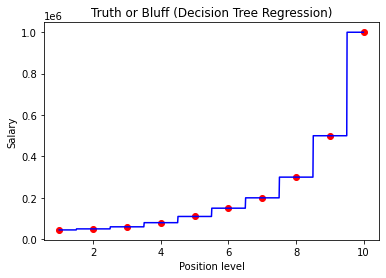

In [5]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()